# 🛒 Model 1 — Next Purchase Prediction 

**Input:** Customer purchase history from PostgreSQL DB  
**Output:** Customer segments grouped by predicted next product → fed into Campaign System  

| Stage | Description |
|-------|-------------|
| **1** | Load from PostgreSQL (fallback: CSV) + Point-in-time Feature Engineering |
| **2** | Cold-Start Handling (single-purchase customers) |
| **3** | Multi-Algorithm Comparison (LightGBM · XGBoost · RandomForest) → Best Model |
| **4** | Optuna Hyperparameter Tuning on Best Model |
| **5** | Stage 2 — Candidate Generation + Smart Negative Sampling + LambdaRank + Optuna |
| **6** | Evaluation: Hit@K · Recall@K · NDCG@K · MAP@K |
| **7** | Save / Load · Single-user (from DB) · CSV/DB Batch · Customer Segments |
| **8** | Predictions & Segments → PostgreSQL |
| **9** | Flask API |


In [1]:
1+1

2

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import optuna
import pickle, os, json, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, classification_report,
                              top_k_accuracy_score)

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
np.random.seed(42)

MODEL_VERSION = "v1.0"
print("All imports OK")


All imports OK


---
## Stage 1 — Load Data from PostgreSQL (+ Feature Engineering)

### 1.1 Load from PostgreSQL  
> Production: reads `v_customer_purchase_history` view.  
> Dev/fallback: reads CSV if DB not reachable.

In [3]:
def load_from_postgres():
    from db_connector import DBConnector
    db = DBConnector()
    if not db.health_check():
        raise ConnectionError("DB not reachable")
    return db.load_purchase_history()

try:
    df = load_from_postgres()
    DATA_SOURCE = "PostgreSQL"
    print(f"Loaded {len(df):,} rows from PostgreSQL")
except Exception as e:
    print(f"PostgreSQL not available ({e}) — falling back to CSV")
    df = pd.read_csv('ecommerce_next_purchase_dataset.csv')
    DATA_SOURCE = "CSV"

df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['signup_date']   = pd.to_datetime(df['signup_date'])
df['days_since_last_purchase'] = pd.to_numeric(
    df.get('days_since_last_purchase', np.nan), errors='coerce')
df = df.sort_values(['customer_id','purchase_date','purchase_number']).reset_index(drop=True)
print(f"Data source: {DATA_SOURCE} | Shape: {df.shape}")
df.head(3)


Loaded 60,069 rows from PostgreSQL
Data source: PostgreSQL | Shape: (60069, 28)


,customer_id,age,gender,city,state,signup_date,order_id,purchase_date,purchase_number,product_id,product_name,brand,category,subcategory,price,discount,quantity,net_amount,product_rating,product_popularity,device,traffic_source,search_keyword,pages_viewed,wishlist_items,cart_items,interaction_score,days_since_last_purchase
0,C00001,32.0,Female,Mumbai,Maharashtra,2024-02-02,O0000001,2024-08-18,1,P00365,Bloomsbury Non-Fiction Aut,Bloomsbury,Books,Non-Fiction,1304.21,15.0,1,1108.58,4.7,125,Mobile,Paid Ads,porro,9,0,4,0.748,NaN
1,C00001,32.0,Female,Mumbai,Maharashtra,2024-02-02,O0000002,2025-11-21,2,P00361,HarperCollins Non-Fiction Tenetur,HarperCollins,Books,Non-Fiction,825.15,20.0,1,660.12,3.5,408,Mobile,Organic Search,Non-Fiction,6,2,2,0.889,NaN
2,C00001,32.0,Female,Mumbai,Maharashtra,2024-02-02,O_96c2d2d536ca42ee90c0,2026-07-10,3,P00001,Samsung Mobile Tempore,Samsung,Electronics,Mobiles,30463.58,0.0,1,30463.58,4.7,183,None,None,None,0,0,0,0.000,NaN


### 1.2 Build Sequence Targets (ZERO Leakage)

In [4]:
df['next_category']     = df.groupby('customer_id')['category'].shift(-1)
df['next_subcategory']  = df.groupby('customer_id')['subcategory'].shift(-1)
df['next_product_name'] = df.groupby('customer_id')['product_name'].shift(-1)
df['next_product_id']   = df.groupby('customer_id')['product_id'].shift(-1)

# all rows — split later by cold-start
model_df = df.dropna(subset=['next_category','next_product_name']).copy()
model_df = model_df.sort_values(['customer_id','purchase_date','purchase_number']).reset_index(drop=True)
print(f"Rows with future label: {len(model_df):,} | Dropped: {len(df)-len(model_df):,}")
model_df['next_category'].value_counts()


Rows with future label: 52,139 | Dropped: 7,930


next_category
Beauty         8241
Sports         7736
Home           7666
Fashion        7406
Books          7241
Electronics    7077
Grocery        6772
Name: count, dtype: int64

### 1.3 Point-in-Time Customer Feature Engineering
> Every feature at row `t` uses ONLY purchases `1 .. t-1`.

In [5]:
model_df['net_amount'] = model_df['price']*model_df['quantity']*(1-model_df['discount']/100)
g = model_df.groupby('customer_id')

model_df['cum_orders_so_far']       = g.cumcount()
model_df['cum_spent_so_far']        = g['net_amount'].apply(lambda s: s.shift(1).cumsum()).reset_index(drop=True)
model_df['cum_avg_price_so_far']    = g['price'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(drop=True)
model_df['cum_avg_discount_so_far'] = g['discount'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(drop=True)
model_df['cum_avg_rating_so_far']   = g['product_rating'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(drop=True)
model_df['prev_purchase_date']      = g['purchase_date'].shift(1)
model_df['days_since_prev_purchase']= (model_df['purchase_date']-model_df['prev_purchase_date']).dt.days
model_df['avg_gap_between_purchases']=(
    model_df.groupby('customer_id')['days_since_prev_purchase']
    .apply(lambda s: s.shift(1).expanding().mean()).reset_index(drop=True))
model_df['days_since_signup']       = (model_df['purchase_date']-model_df['signup_date']).dt.days
model_df['purchase_month']          = model_df['purchase_date'].dt.month
model_df['purchase_quarter']        = model_df['purchase_date'].dt.quarter
model_df['purchase_dayofweek']      = model_df['purchase_date'].dt.dayofweek

def running_mode(series):
    counts, out = {}, []
    for v in series:
        out.append(max(counts, key=counts.get) if counts else np.nan)
        counts[v] = counts.get(v, 0) + 1
    return pd.Series(out, index=series.index)

def running_nunique(series):
    seen, out = set(), []
    for v in series:
        out.append(len(seen)); seen.add(v)
    return pd.Series(out, index=series.index)

g = model_df.groupby('customer_id')
model_df['most_frequent_category_so_far'] = g['category'].apply(running_mode).reset_index(drop=True)
model_df['most_frequent_brand_so_far']    = g['brand'].apply(running_mode).reset_index(drop=True)
model_df['prev_category']                 = g['category'].shift(1)
model_df['prev_subcategory']              = g['subcategory'].shift(1)
model_df['prev_brand']                    = g['brand'].shift(1)
model_df['n_unique_categories_so_far']    = g['category'].apply(running_nunique).reset_index(drop=True)
model_df['is_cold_start']                 = (model_df['cum_orders_so_far'] == 0).astype(int)

print("Feature engineering done.")
print(f"Cold-start rows (1st purchase): {model_df['is_cold_start'].sum():,}")
print(f"Warm rows (2+ purchases)      : {(model_df['is_cold_start']==0).sum():,}")


Feature engineering done.
Cold-start rows (1st purchase): 7,433
Warm rows (2+ purchases)      : 44,706


### 1.4 Product Feature Engineering

In [6]:
product_stats = df.groupby('product_name').agg(
    prod_global_avg_rating   = ('product_rating', 'mean'),
    prod_global_popularity   = ('product_popularity', 'max'),
    prod_total_orders        = ('order_id', 'nunique'),
    prod_avg_discount_given  = ('discount', 'mean'),
    prod_avg_qty_sold        = ('quantity', 'mean'),
).reset_index()

product_catalog = (
    df.groupby('product_name')
      .agg(product_id  =('product_id','first'),
           category    =('category','first'),
           subcategory =('subcategory','first'),
           brand       =('brand','first'),
           price       =('price','mean'))
      .reset_index()
      .merge(product_stats, on='product_name')
)
cat_to_products = product_catalog.groupby('category')['product_name'].apply(list).to_dict()
all_categories  = list(cat_to_products.keys())
print(f"Product catalog: {product_catalog.shape[0]} products, {len(all_categories)} categories")


Product catalog: 401 products, 7 categories


---
## Stage 2 — Cold-Start Handling (Single-Purchase Customers)

In [7]:
cold_df = model_df[model_df['is_cold_start'] == 1].copy()
warm_df = model_df[model_df['is_cold_start'] == 0].copy()

print(f"Cold-start customers: {cold_df['customer_id'].nunique():,}")
print(f"Warm customers      : {warm_df['customer_id'].nunique():,}")

# Cold-start strategy: popularity within demographic (age_group x gender x city)
# Step 1: compute global popularity per (category, demographic bucket)
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,60,100],
                          labels=['<25','25-35','35-45','45-60','60+'])

pop_by_demo = (
    df.groupby(['age_group','gender','category'])
      .agg(demo_order_count=('order_id','nunique'))
      .reset_index()
      .sort_values('demo_order_count', ascending=False)
)

def cold_start_recommend(age, gender, top_n=5):
    age_grp = pd.cut([age], bins=[0,25,35,45,60,100],
                      labels=['<25','25-35','35-45','45-60','60+'])[0]
    match = pop_by_demo[
        (pop_by_demo['age_group'] == age_grp) &
        (pop_by_demo['gender'] == gender)
    ].head(top_n)
    if len(match) == 0:
        match = pop_by_demo.head(top_n)  # global fallback
    # For each top category, return top product by popularity
    recs = []
    for cat in match['category']:
        prods = product_catalog[product_catalog['category']==cat].sort_values(
            'prod_global_popularity', ascending=False).head(1)
        if len(prods) > 0:
            recs.append({
                'predicted_category'  : cat,
                'recommended_product' : prods.iloc[0]['product_name'],
                'strategy'            : 'cold_start_demographic',
            })
    return recs

# Demo
print("Cold-start recommendation for Age=23, Gender=Female:")
for r in cold_start_recommend(23, 'Female', top_n=3):
    print(f"  {r['predicted_category']:20s} → {r['recommended_product']}")


Cold-start customers: 7,433
Warm customers      : 6,481
Cold-start recommendation for Age=23, Gender=Female:
  Beauty               → Maybelline Makeup Beatae
  Fashion              → Puma Bag Fuga
  Home                 → Urban Ladder Furniture Ratione


---
## Stage 3 — Multi-Algorithm Comparison

### 3.1 Feature Lists

In [8]:
CUSTOMER_STATIC  = ['age','gender','city','state']
HISTORY_FEATURES = [
    'cum_orders_so_far','cum_spent_so_far','cum_avg_price_so_far',
    'cum_avg_discount_so_far','cum_avg_rating_so_far',
    'days_since_prev_purchase','avg_gap_between_purchases','days_since_signup',
    'n_unique_categories_so_far','purchase_month','purchase_quarter','purchase_dayofweek',
]
AFFINITY_FEATURES = [
    'most_frequent_category_so_far','most_frequent_brand_so_far',
    'prev_category','prev_subcategory','prev_brand',
]
SESSION_FEATURES = [
    'pages_viewed','wishlist_items','cart_items',
    'interaction_score','device','traffic_source','search_keyword',
]

FEATURE_COLS = CUSTOMER_STATIC + HISTORY_FEATURES + AFFINITY_FEATURES + SESSION_FEATURES
TARGET_CAT   = 'next_category'
print(f"Feature count: {len(FEATURE_COLS)}")


Feature count: 28


### 3.2 Encode + GroupShuffleSplit

In [9]:
data = warm_df[FEATURE_COLS + [TARGET_CAT,'next_product_name','next_product_id','customer_id']].copy()

num_cols = data[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = data[FEATURE_COLS].select_dtypes(include='object').columns.tolist()

data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna('Unknown')

s1_label_encoders = {}
for c in cat_cols:
    le = LabelEncoder(); data[c] = le.fit_transform(data[c].astype(str))
    s1_label_encoders[c] = le

cat_target_encoder = LabelEncoder()
data[TARGET_CAT] = cat_target_encoder.fit_transform(data[TARGET_CAT])
n_classes = len(cat_target_encoder.classes_)

X = data[FEATURE_COLS]; y = data[TARGET_CAT]; groups = data['customer_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y.iloc[train_idx].reset_index(drop=True), y.iloc[test_idx].reset_index(drop=True)
test_raw  = warm_df.iloc[test_idx].reset_index(drop=True)
train_raw = warm_df.iloc[train_idx].reset_index(drop=True)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}  |  Classes: {n_classes}")
print("Categories:", cat_target_encoder.classes_)


Train: (35703, 28)  |  Test: (9003, 28)  |  Classes: 7
Categories: ['Beauty' 'Books' 'Electronics' 'Fashion' 'Grocery' 'Home' 'Sports']


### 3.3 Train 3 Algorithms — Compare Accuracy

In [10]:
results = {}

# ── 1. LightGBM ──────────────────────────────────────────────
lgb_ts = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
lgb_vs = lgb.Dataset(X_test,  label=y_test,  categorical_feature=cat_cols, reference=lgb_ts)
lgb_model = lgb.train(
    {'objective':'multiclass','num_class':n_classes,'metric':'multi_logloss',
     'learning_rate':0.05,'num_leaves':64,'feature_fraction':0.85,
     'bagging_fraction':0.85,'bagging_freq':5,'min_data_in_leaf':30,
     'verbose':-1,'seed':42},
    lgb_ts, 500, valid_sets=[lgb_vs], valid_names=['valid'],
    callbacks=[lgb.early_stopping(40), lgb.log_evaluation(100)],
)
lgb_prob = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
lgb_pred = lgb_prob.argmax(axis=1)
results['LightGBM'] = {
    'model'   : lgb_model,
    'proba'   : lgb_prob,
    'top1'    : accuracy_score(y_test, lgb_pred),
    'top3'    : top_k_accuracy_score(y_test, lgb_prob, k=3, labels=np.arange(n_classes)),
}
print(f"LightGBM  Top-1: {results['LightGBM']['top1']:.4f}  Top-3: {results['LightGBM']['top3']:.4f}")


Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[41]	valid's multi_logloss: 1.29211
LightGBM  Top-1: 0.6281  Top-3: 0.7888


In [11]:
# ── 2. XGBoost ───────────────────────────────────────────────
dtr = xgb.DMatrix(X_train, label=y_train)
dte = xgb.DMatrix(X_test,  label=y_test)
xgb_model = xgb.train(
    {'objective':'multi:softprob','num_class':n_classes,'eval_metric':'mlogloss',
     'learning_rate':0.05,'max_depth':6,'n_estimators':500,
     'subsample':0.85,'colsample_bytree':0.85,'verbosity':0,'seed':42},
    dtr, 500, evals=[(dte,'val')],
    verbose_eval=False, early_stopping_rounds=40,
)
xgb_prob = xgb_model.predict(dte).reshape(-1, n_classes)
xgb_pred = xgb_prob.argmax(axis=1)
results['XGBoost'] = {
    'model': xgb_model,
    'proba': xgb_prob,
    'top1' : accuracy_score(y_test, xgb_pred),
    'top3' : top_k_accuracy_score(y_test, xgb_prob, k=3, labels=np.arange(n_classes)),
}
print(f"XGBoost   Top-1: {results['XGBoost']['top1']:.4f}  Top-3: {results['XGBoost']['top3']:.4f}")


XGBoost   Top-1: 0.6226  Top-3: 0.7851


In [12]:
# ── 3. RandomForest (sampled — RF is slow on 35k+ rows) ──────
from sklearn.ensemble import RandomForestClassifier
SAMPLE = 15000
idx_s  = np.random.choice(len(X_train), SAMPLE, replace=False)
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=10,
    n_jobs=-1, random_state=42,
)
rf_model.fit(X_train.iloc[idx_s], y_train.iloc[idx_s])
rf_prob = rf_model.predict_proba(X_test)
rf_pred = rf_prob.argmax(axis=1)
results['RandomForest'] = {
    'model': rf_model,
    'proba': rf_prob,
    'top1' : accuracy_score(y_test, rf_pred),
    'top3' : top_k_accuracy_score(y_test, rf_prob, k=3, labels=np.arange(n_classes)),
}
print(f"RandomForest  Top-1: {results['RandomForest']['top1']:.4f}  Top-3: {results['RandomForest']['top3']:.4f}")


RandomForest  Top-1: 0.6164  Top-3: 0.7722


  Model Comparison
   Algorithm  Top-1 Accuracy  Top-3 Accuracy
    LightGBM        0.628124        0.788848
     XGBoost        0.622570        0.785072
RandomForest        0.616350        0.772187


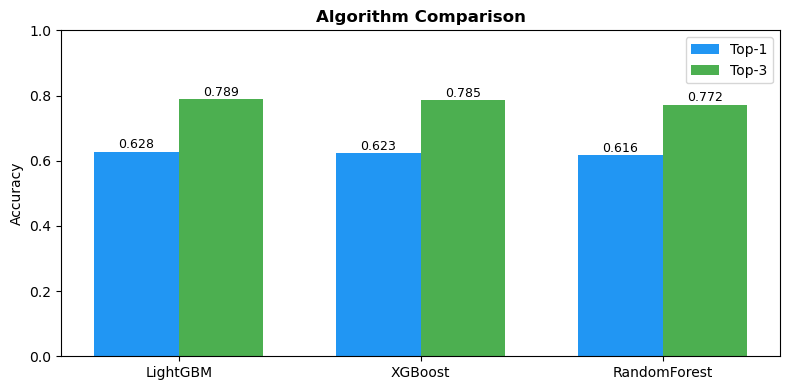

Best algorithm: LightGBM


In [13]:
# ── Comparison Table ─────────────────────────────────────────
comp_df = pd.DataFrame([
    {'Algorithm': algo, 'Top-1 Accuracy': r['top1'], 'Top-3 Accuracy': r['top3']}
    for algo, r in results.items()
]).sort_values('Top-1 Accuracy', ascending=False).reset_index(drop=True)
print("=" * 55)
print("  Model Comparison")
print("=" * 55)
print(comp_df.to_string(index=False))
print("=" * 55)

fig, ax = plt.subplots(figsize=(8,4))
x = np.arange(len(comp_df))
w = 0.35
ax.bar(x-w/2, comp_df['Top-1 Accuracy'], w, label='Top-1', color='#2196F3')
ax.bar(x+w/2, comp_df['Top-3 Accuracy'], w, label='Top-3', color='#4CAF50')
ax.set_xticks(x); ax.set_xticklabels(comp_df['Algorithm'])
ax.set_ylim(0, 1); ax.set_ylabel('Accuracy'); ax.legend()
ax.set_title('Algorithm Comparison', fontweight='bold')
for i, (t1, t3) in enumerate(zip(comp_df['Top-1 Accuracy'], comp_df['Top-3 Accuracy'])):
    ax.text(i-w/2, t1+0.01, f'{t1:.3f}', ha='center', fontsize=9)
    ax.text(i+w/2, t3+0.01, f'{t3:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

BEST_ALGO = comp_df.iloc[0]['Algorithm']
print(f"Best algorithm: {BEST_ALGO}")


---
## Stage 4 — Optuna Hyperparameter Tuning on Best Model

In [14]:
# Optuna tunes only LightGBM (best algo from comparison above)
# Each trial creates fresh dataset to avoid feature_pre_filter mismatch

def objective_lgb(trial):
    params = {
        'objective'          : 'multiclass',
        'num_class'          : n_classes,
        'metric'             : 'multi_logloss',
        'feature_pre_filter' : False,
        'learning_rate'      : trial.suggest_float('learning_rate',   0.03, 0.15, log=True),
        'num_leaves'         : trial.suggest_int('num_leaves',        31, 127),
        'max_depth'          : trial.suggest_int('max_depth',         4, 10),
        'min_data_in_leaf'   : trial.suggest_int('min_data_in_leaf',  10, 80),
        'feature_fraction'   : trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction'   : trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq'       : 5,
        'lambda_l1'          : trial.suggest_float('lambda_l1',       1e-4, 5.0, log=True),
        'lambda_l2'          : trial.suggest_float('lambda_l2',       1e-4, 5.0, log=True),
        'verbose'            : -1,
        'seed'               : 42,
    }
    _ts = lgb.Dataset(X_train, label=y_train,
                      categorical_feature=cat_cols, free_raw_data=False)
    _vs = lgb.Dataset(X_test,  label=y_test,
                      categorical_feature=cat_cols, reference=_ts, free_raw_data=False)
    m = lgb.train(params, _ts, num_boost_round=200,
                  valid_sets=[_vs], valid_names=['valid'],
                  callbacks=[lgb.early_stopping(20), lgb.log_evaluation(999)])
    preds = m.predict(X_test, num_iteration=m.best_iteration)
    return accuracy_score(y_test, preds.argmax(axis=1))


def objective_xgb(trial):
    params = {
        'objective'       : 'multi:softprob',
        'num_class'       : n_classes,
        'eval_metric'     : 'mlogloss',
        'learning_rate'   : trial.suggest_float('learning_rate',    0.03, 0.15, log=True),
        'max_depth'       : trial.suggest_int('max_depth',          3, 8),
        'subsample'       : trial.suggest_float('subsample',        0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight',   1, 20),
        'reg_alpha'       : trial.suggest_float('reg_alpha',        1e-4, 5.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda',       1e-4, 5.0, log=True),
        'verbosity'       : 0, 'seed': 42,
    }
    m = xgb.train(params, dtr, 200, evals=[(dte,'val')],
                  verbose_eval=False, early_stopping_rounds=20)
    preds = m.predict(dte).reshape(-1, n_classes)
    return accuracy_score(y_test, preds.argmax(axis=1))


objectives = {'LightGBM': objective_lgb, 'XGBoost': objective_xgb}
objective_fn = objectives.get(BEST_ALGO, objective_lgb)
print(f"Running Optuna on: {BEST_ALGO} (10 trials)")
study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective_fn, n_trials=10, show_progress_bar=True)
print(f"Best Top-1 accuracy: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Running Optuna on: LightGBM (10 trials)


  0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[37]	valid's multi_logloss: 1.2958
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[27]	valid's multi_logloss: 1.2927
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[42]	valid's multi_logloss: 1.29608
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[32]	valid's multi_logloss: 1.29219
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[62]	valid's multi_logloss: 1.29485
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[62]	valid's multi_logloss: 1.28684
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[26]	valid's multi_logloss: 1.2932
Training until validation scores don't improve for 20 rounds
Early stopping, be

In [15]:
# Train final model with Optuna best params
best_params = study.best_params.copy()

if BEST_ALGO == 'LightGBM':
    best_params.update({
        'objective': 'multiclass', 'num_class': n_classes,
        'metric': 'multi_logloss', 'feature_pre_filter': False,
        'verbose': -1, 'seed': 42,
    })
    _ts_final = lgb.Dataset(X_train, label=y_train,
                             categorical_feature=cat_cols, free_raw_data=False)
    _vs_final = lgb.Dataset(X_test,  label=y_test,
                             categorical_feature=cat_cols,
                             reference=_ts_final, free_raw_data=False)
    final_model = lgb.train(
        best_params, _ts_final, num_boost_round=500,
        valid_sets=[_vs_final], valid_names=['valid'],
        callbacks=[lgb.early_stopping(40), lgb.log_evaluation(100)],
    )
    final_prob = final_model.predict(X_test, num_iteration=final_model.best_iteration)

else:  # XGBoost
    best_params.update({'objective':'multi:softprob','num_class':n_classes,
                        'eval_metric':'mlogloss','verbosity':0,'seed':42})
    final_model = xgb.train(
        best_params, dtr, 500, evals=[(dte,'val')],
        verbose_eval=False, early_stopping_rounds=40,
    )
    final_prob = final_model.predict(dte).reshape(-1, n_classes)

final_pred = final_prob.argmax(axis=1)
final_top1 = accuracy_score(y_test, final_pred)
final_top3 = top_k_accuracy_score(y_test, final_prob, k=3,
                                   labels=np.arange(n_classes))

print(f"Final {BEST_ALGO} + Optuna — Top-1: {final_top1:.4f}  Top-3: {final_top3:.4f}")
print()
print(classification_report(y_test, final_pred,
      target_names=cat_target_encoder.classes_, zero_division=0))

# Use this as cat_model going forward
cat_model = final_model
ALGO_TYPE  = BEST_ALGO


Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[33]	valid's multi_logloss: 1.2879
Final LightGBM + Optuna — Top-1: 0.6275  Top-3: 0.7891

              precision    recall  f1-score   support

      Beauty       0.64      0.59      0.61      1386
       Books       0.63      0.63      0.63      1186
 Electronics       0.61      0.63      0.62      1154
     Fashion       0.63      0.60      0.61      1330
     Grocery       0.62      0.71      0.66      1209
        Home       0.63      0.59      0.61      1351
      Sports       0.64      0.65      0.64      1387

    accuracy                           0.63      9003
   macro avg       0.63      0.63      0.63      9003
weighted avg       0.63      0.63      0.63      9003



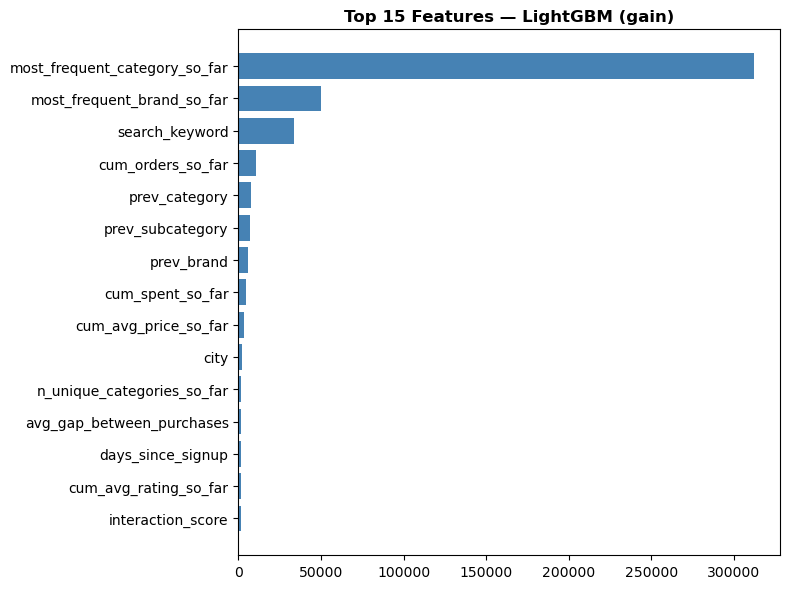

,feature,importance
0,most_frequent_category_so_far,312205.216721
1,most_frequent_brand_so_far,50235.331301
2,search_keyword,33845.947330
3,cum_orders_so_far,10792.891546
4,prev_category,7465.823681
5,prev_subcategory,7006.308074
6,prev_brand,5569.876237
7,cum_spent_so_far,4480.895791
8,cum_avg_price_so_far,3340.709375
9,city,2249.812096


In [16]:
# Feature importance
if ALGO_TYPE == 'LightGBM':
    imp_vals = cat_model.feature_importance(importance_type='gain')
else:
    imp_vals = cat_model.get_score(importance_type='gain')
    imp_vals = [imp_vals.get(f, 0) for f in FEATURE_COLS]

imp_df = pd.DataFrame({'feature':FEATURE_COLS,'importance':imp_vals}
                      ).sort_values('importance',ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(imp_df['feature'][:15][::-1], imp_df['importance'][:15][::-1], color='steelblue')
ax.set_title(f'Top 15 Features — {ALGO_TYPE} (gain)', fontweight='bold')
plt.tight_layout(); plt.show()
imp_df.head(15)


---
## Stage 5 — LambdaRank: Candidate Generation + Smart Negatives + Optuna

### 5.1 Candidate Generation + Smart Negative Sampling

In [17]:
# Stage 1 predicted categories for both splits
def get_predicted_cat(X_split):
    if ALGO_TYPE == 'LightGBM':
        prob = cat_model.predict(X_split, num_iteration=cat_model.best_iteration)
    else:
        prob = cat_model.predict(xgb.DMatrix(X_split)).reshape(-1, n_classes)
    return cat_target_encoder.inverse_transform(prob.argmax(axis=1))

train_raw['predicted_category'] = get_predicted_cat(X_train)
test_raw['predicted_category']  = get_predicted_cat(X_test)
print("Candidate categories predicted for train & test splits.")


Candidate categories predicted for train & test splits.


In [18]:
def build_ranking_pairs(split_df, split_X, n_hard=3, n_easy=2):
    rows = []
    split_X  = split_X.reset_index(drop=True)
    split_df = split_df.reset_index(drop=True)

    for idx in range(len(split_df)):
        raw        = split_df.iloc[idx]
        cust_feat  = split_X.iloc[idx].to_dict()
        true_prod  = raw['next_product_name']
        pred_cat   = raw['predicted_category']

        pm = product_catalog[product_catalog['product_name'] == true_prod]
        if len(pm) == 0: continue
        pm = pm.iloc[0]

        def make_row(p, label):
            return {**cust_feat,
                'prod_category'    : p['category'],
                'prod_subcategory' : p['subcategory'],
                'prod_brand'       : p['brand'],
                'prod_price'       : p['price'],
                'prod_avg_rating'  : p['prod_global_avg_rating'],
                'prod_popularity'  : p['prod_global_popularity'],
                'prod_total_orders': p['prod_total_orders'],
                'prod_avg_discount': p['prod_avg_discount_given'],
                'prod_avg_qty'     : p['prod_avg_qty_sold'],
                'brand_match'      : int(p['brand'] == str(raw.get('most_frequent_brand_so_far',''))),
                'category_match'   : int(p['category'] == str(raw.get('most_frequent_category_so_far',''))),
                'price_diff_from_avg': p['price'] - float(raw.get('cum_avg_price_so_far', p['price'])),
                'label': label, 'query_id': idx,
            }

        rows.append(make_row(pm, 1))

        # Hard negatives — same predicted category
        same = [p for p in cat_to_products.get(pred_cat,[]) if p != true_prod]
        for pn in (np.random.choice(same, min(n_hard,len(same)), replace=False) if same else []):
            p2 = product_catalog[product_catalog['product_name']==pn]
            if len(p2)>0: rows.append(make_row(p2.iloc[0], 0))

        # Easy negatives — different category
        for _ in range(n_easy):
            oc   = np.random.choice([c for c in all_categories if c!=pred_cat])
            pool = cat_to_products.get(oc,[])
            if not pool: continue
            p3   = product_catalog[product_catalog['product_name']==np.random.choice(pool)]
            if len(p3)>0: rows.append(make_row(p3.iloc[0], 0))

    return pd.DataFrame(rows)

RANK_SAMPLE = 8000
print("Building train ranking pairs...")
train_pairs = build_ranking_pairs(
    train_raw.sample(min(RANK_SAMPLE,len(train_raw)), random_state=42).reset_index(drop=True),
    X_train.iloc[:min(RANK_SAMPLE,len(train_raw))],
)
print(f"Train: {len(train_pairs):,} | Pos: {train_pairs['label'].sum():,}")
print("Building test ranking pairs...")
test_pairs = build_ranking_pairs(
    test_raw.sample(min(RANK_SAMPLE//4,len(test_raw)), random_state=42).reset_index(drop=True),
    X_test.iloc[:min(RANK_SAMPLE//4,len(test_raw))],
)
print(f"Test:  {len(test_pairs):,} | Pos: {test_pairs['label'].sum():,}")


Building train ranking pairs...
Train: 48,000 | Pos: 8,000
Building test ranking pairs...
Test:  12,000 | Pos: 2,000


### 5.2 Encode Rank Features

In [19]:
RANK_PRODUCT_FEATURES = ['prod_price','prod_avg_rating','prod_popularity','prod_total_orders',
                          'prod_avg_discount','prod_avg_qty','brand_match','category_match',
                          'price_diff_from_avg']
RANK_CAT_PRODUCT = ['prod_category','prod_subcategory','prod_brand']
RANK_FEATURES    = FEATURE_COLS + RANK_PRODUCT_FEATURES + RANK_CAT_PRODUCT

def prep_rank(pairs_df):
    d = pairs_df[RANK_FEATURES + ['label','query_id']].copy()
    d[d[RANK_FEATURES].select_dtypes(include=[np.number]).columns] =         d[d[RANK_FEATURES].select_dtypes(include=[np.number]).columns].fillna(
        d[d[RANK_FEATURES].select_dtypes(include=[np.number]).columns].median())
    cat = d[RANK_FEATURES].select_dtypes(include='object').columns.tolist()
    d[cat] = d[cat].fillna('Unknown')
    return d, cat

train_rank, rank_cat_cols = prep_rank(train_pairs)
test_rank,  _             = prep_rank(test_pairs)
rank_encoders = {}
for c in rank_cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train_rank[c],test_rank[c]]).astype(str))
    train_rank[c] = le.transform(train_rank[c].astype(str))
    test_rank[c]  = le.transform(test_rank[c].astype(str))
    rank_encoders[c] = le
print(f"Rank features: {len(RANK_FEATURES)}")


Rank features: 40


### 5.3 LambdaRank + Optuna

In [20]:
rts = lgb.Dataset(train_rank[RANK_FEATURES], label=train_rank['label'],
                   group=train_rank.groupby('query_id').size().values,
                   categorical_feature=rank_cat_cols, free_raw_data=False)
rvs = lgb.Dataset(test_rank[RANK_FEATURES],  label=test_rank['label'],
                   group=test_rank.groupby('query_id').size().values,
                   categorical_feature=rank_cat_cols,
                   reference=rts, free_raw_data=False)

def rank_objective(trial):
    p = {
        'objective'          : 'lambdarank',
        'metric'             : 'ndcg',
        'ndcg_eval_at'       : [5],
        'feature_pre_filter' : False,
        'learning_rate'      : trial.suggest_float('lr',  0.03, 0.2, log=True),
        'num_leaves'         : trial.suggest_int('nl',    31, 127),
        'feature_fraction'   : trial.suggest_float('ff',  0.6, 1.0),
        'bagging_fraction'   : trial.suggest_float('bf',  0.6, 1.0),
        'bagging_freq'       : 5,
        'min_data_in_leaf'   : trial.suggest_int('mdl',   5, 40),
        'label_gain'         : [0, 1],
        'verbose'            : -1, 'seed': 42,
    }
    # Fresh dataset each trial to avoid pre_filter mismatch
    _rts = lgb.Dataset(train_rank[RANK_FEATURES], label=train_rank['label'],
                        group=train_rank.groupby('query_id').size().values,
                        categorical_feature=rank_cat_cols, free_raw_data=False)
    _rvs = lgb.Dataset(test_rank[RANK_FEATURES],  label=test_rank['label'],
                        group=test_rank.groupby('query_id').size().values,
                        categorical_feature=rank_cat_cols,
                        reference=_rts, free_raw_data=False)
    m = lgb.train(p, _rts, 200, valid_sets=[_rvs], valid_names=['v'],
                  callbacks=[lgb.early_stopping(20), lgb.log_evaluation(999)])
    return m.best_score['v']['ndcg@5']

print("Optuna on LambdaRank (8 trials)...")
rank_study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
rank_study.optimize(rank_objective, n_trials=8, show_progress_bar=True)
print(f"Best NDCG@5: {rank_study.best_value:.4f}")

# Train final rank model
rp = rank_study.best_params.copy()
rp.update({'objective':'lambdarank','metric':'ndcg','ndcg_eval_at':[1,3,5,10],
            'label_gain':[0,1],'bagging_freq':5,'feature_pre_filter':False,
            'verbose':-1,'seed':42})

_rts_f = lgb.Dataset(train_rank[RANK_FEATURES], label=train_rank['label'],
                      group=train_rank.groupby('query_id').size().values,
                      categorical_feature=rank_cat_cols, free_raw_data=False)
_rvs_f = lgb.Dataset(test_rank[RANK_FEATURES],  label=test_rank['label'],
                      group=test_rank.groupby('query_id').size().values,
                      categorical_feature=rank_cat_cols, reference=_rts_f, free_raw_data=False)

rank_model = lgb.train(rp, _rts_f, 500,
                        valid_sets=[_rvs_f], valid_names=['valid'],
                        callbacks=[lgb.early_stopping(40), lgb.log_evaluation(50)])
print("LambdaRank trained. Best iteration:", rank_model.best_iteration)


Optuna on LambdaRank (8 trials)...


  0%|          | 0/8 [00:00<?, ?it/s]

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	v's ndcg@5: 0.711858
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	v's ndcg@5: 0.726624
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	v's ndcg@5: 0.701434
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	v's ndcg@5: 0.720584
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	v's ndcg@5: 0.721626
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	v's ndcg@5: 0.723976
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	v's ndcg@5: 0.722661
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	v's ndcg@5: 0.719053
Best NDCG@5: 0.7266
Training unt

In [21]:
# LambdaRank final model trained in cell above — this cell intentionally skipped
print('LambdaRank model ready.')

LambdaRank model ready.


---
## Stage 6 — Evaluation: Hit@K · Recall@K · NDCG@K · MAP@K

In [22]:
def compute_metrics(pairs_df, enc_df, model, features, k_list=[1,3,5,10]):
    out = {f'{m}@{k}':[] for m in ['Hit','Recall','NDCG','MAP'] for k in k_list}
    scores = model.predict(enc_df[features], num_iteration=model.best_iteration)
    p = pairs_df.copy(); p['score'] = scores
    for _, grp in p.groupby('query_id'):
        rel   = grp.sort_values('score',ascending=False)['label'].tolist()
        n_rel = sum(rel)
        if n_rel == 0: continue
        for k in k_list:
            topk = rel[:k]
            out[f'Hit@{k}'].append(int(any(r==1 for r in topk)))
            out[f'Recall@{k}'].append(sum(topk)/n_rel)
            dcg  = sum((2**r-1)/np.log2(i+2) for i,r in enumerate(topk))
            idcg = sum((2**r-1)/np.log2(i+2) for i,r in enumerate(sorted(topk,reverse=True)))
            out[f'NDCG@{k}'].append(dcg/idcg if idcg>0 else 0)
            ap,h = 0.0,0
            for i,r in enumerate(topk):
                if r==1: h+=1; ap+=h/(i+1)
            out[f'MAP@{k}'].append(ap/min(n_rel,k))
    return {k:np.mean(v) for k,v in out.items()}

m = compute_metrics(test_pairs, test_rank, rank_model, RANK_FEATURES)

print("=" * 70)
print(f"  Category Model ({ALGO_TYPE}+Optuna)  "
      f"Top-1={final_top1:.4f}  Top-3={final_top3:.4f}")
print("=" * 70)
for k in [1,3,5,10]:
    print(f"  K={k:2d}  Hit={m[f'Hit@{k}']:.4f}  "
          f"Recall={m[f'Recall@{k}']:.4f}  "
          f"NDCG={m[f'NDCG@{k}']:.4f}  "
          f"MAP={m[f'MAP@{k}']:.4f}")
print("=" * 70)


  Category Model (LightGBM+Optuna)  Top-1=0.6275  Top-3=0.7891
  K= 1  Hit=0.4500  Recall=0.4500  NDCG=0.4500  MAP=0.4500
  K= 3  Hit=0.8065  Recall=0.8065  NDCG=0.6565  MAP=0.6048
  K= 5  Hit=0.9765  Recall=0.9765  NDCG=0.7271  MAP=0.6443
  K=10  Hit=1.0000  Recall=1.0000  NDCG=0.7355  MAP=0.6483


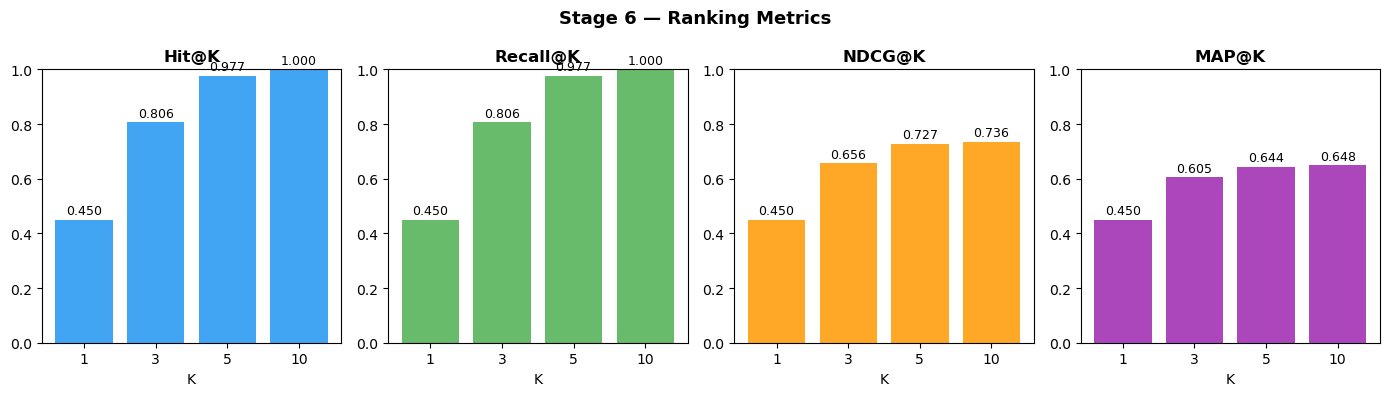

In [23]:
ks=[1,3,5,10]; mn=['Hit@K','Recall@K','NDCG@K','MAP@K']
cl=['#2196F3','#4CAF50','#FF9800','#9C27B0']
fig, axes = plt.subplots(1,4,figsize=(14,4))
for ax,n,c in zip(axes,mn,cl):
    b=n.split('@')[0]; vs=[m[f'{b}@{k}'] for k in ks]
    ax.bar([str(k) for k in ks],vs,color=c,alpha=0.85)
    ax.set_title(n,fontweight='bold'); ax.set_ylim(0,1); ax.set_xlabel('K')
    for i,v in enumerate(vs): ax.text(i,v+0.02,f'{v:.3f}',ha='center',fontsize=9)
plt.suptitle('Stage 6 — Ranking Metrics',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()


---
## Stage 7 — Save / Load / Predict / Segments

### 7.1 Save All Models

In [24]:
os.makedirs('models', exist_ok=True)

if ALGO_TYPE == 'LightGBM':
    cat_model.save_model('models/stage1_category_model.lgb')
else:
    cat_model.save_model('models/stage1_category_model.xgb')

rank_model.save_model('models/stage2_lambdarank_model.lgb')

artifacts = {
    'algo_type'          : ALGO_TYPE,
    's1_label_encoders'  : s1_label_encoders,
    'cat_target_encoder' : cat_target_encoder,
    'rank_encoders'      : rank_encoders,
    'FEATURE_COLS'       : FEATURE_COLS,
    'RANK_FEATURES'      : RANK_FEATURES,
    'cat_cols'           : cat_cols,
    'rank_cat_cols'      : rank_cat_cols,
    'product_catalog'    : product_catalog,
    'cat_to_products'    : cat_to_products,
    'n_classes'          : n_classes,
    'model_version'      : MODEL_VERSION,
}
with open('models/artifacts.pkl','wb') as f:
    pickle.dump(artifacts, f)

print("Saved: models/stage1_category_model.*")
print("Saved: models/stage2_lambdarank_model.lgb")
print("Saved: models/artifacts.pkl")


Saved: models/stage1_category_model.*
Saved: models/stage2_lambdarank_model.lgb
Saved: models/artifacts.pkl


### 7.2 Load Pipeline

In [25]:
def load_pipeline():
    with open('models/artifacts.pkl','rb') as f:
        art = pickle.load(f)
    if art['algo_type'] == 'LightGBM':
        _cat = lgb.Booster(model_file='models/stage1_category_model.lgb')
    else:
        _cat = xgb.Booster()
        _cat.load_model('models/stage1_category_model.xgb')
    _rank = lgb.Booster(model_file='models/stage2_lambdarank_model.lgb')
    return _cat, _rank, art

cat_model_l, rank_model_l, art = load_pipeline()
print("Loaded:", art['algo_type'], "| version:", art['model_version'])
print("Categories:", art['cat_target_encoder'].classes_)


Loaded: LightGBM | version: v1.0
Categories: ['Beauty' 'Books' 'Electronics' 'Fashion' 'Grocery' 'Home' 'Sports']


### 7.3 Encoding Helpers

In [27]:
def encode_customer_features(raw_row, art):
    row = pd.DataFrame([raw_row])
    for col in art['FEATURE_COLS']:
        if col not in row.columns: row[col] = np.nan
    num_f = row[art['FEATURE_COLS']].select_dtypes(include=[np.number]).columns
    row[num_f] = row[num_f].fillna(0)
    for c in art['cat_cols']:
        le  = art['s1_label_encoders'].get(c)
        val = str(row[c].iloc[0]) if c in row.columns else 'Unknown'
        if le:
            val = val if val in le.classes_ else 'Unknown'
            try: row[c] = le.transform([val])[0]
            except: row[c] = 0
        else: row[c] = 0
    return row[art['FEATURE_COLS']]


def predict_category(enc_row, cat_model, art):
    if art['algo_type'] == 'LightGBM':
        prob = cat_model.predict(enc_row, num_iteration=cat_model.best_iteration)[0]
    else:
        prob = cat_model.predict(xgb.DMatrix(enc_row))[0]
    top3_idx = prob.argsort()[-3:][::-1]
    return prob, [(art['cat_target_encoder'].inverse_transform([i])[0], round(float(prob[i]),4))
                  for i in top3_idx]


def encode_rank_features(cust_enc, prod_row, art):
    row = cust_enc.copy()
    row.update({
        'prod_price'       : prod_row['price'],
        'prod_avg_rating'  : prod_row['prod_global_avg_rating'],
        'prod_popularity'  : prod_row['prod_global_popularity'],
        'prod_total_orders': prod_row['prod_total_orders'],
        'prod_avg_discount': prod_row['prod_avg_discount_given'],
        'prod_avg_qty'     : prod_row['prod_avg_qty_sold'],
        'brand_match'      : int(prod_row['brand']==cust_enc.get('most_frequent_brand_so_far',-1)),
        'category_match'   : int(prod_row['category']==cust_enc.get('most_frequent_category_so_far',-1)),
        'price_diff_from_avg': prod_row['price']-cust_enc.get('cum_avg_price_so_far',prod_row['price']),
    })
    pm = {'prod_category':'category','prod_subcategory':'subcategory','prod_brand':'brand'}
    for c in art['rank_cat_cols']:
        le   = art['rank_encoders'].get(c)
        rval = str(prod_row.get(pm.get(c,c),'Unknown'))
        if le:
            rval = rval if rval in le.classes_ else le.classes_[0]
            row[c] = le.transform([rval])[0]
        else: row[c] = 0
    return row

print("Encoding helpers ready.")


Encoding helpers ready.


### 7.4 Single Customer Prediction (reads customer history from DB)

In [28]:
def build_customer_features_from_history(history_df):
    if len(history_df) == 0:
        return None, True   # cold-start
    h = history_df.sort_values('purchase_date').copy()
    h['purchase_date'] = pd.to_datetime(h['purchase_date'])
    h['signup_date']   = pd.to_datetime(h['signup_date'])
    h['net_amount']    = h['price']*h['quantity']*(1-h['discount']/100)
    n = len(h)
    last = h.iloc[-1]
    is_cold = (n == 1)
    feat = {
        'age'                           : last.get('age', 0),
        'gender'                        : last.get('gender','Unknown'),
        'city'                          : last.get('city','Unknown'),
        'state'                         : last.get('state','Unknown'),
        'cum_orders_so_far'             : n - 1,
        'cum_spent_so_far'              : h['net_amount'].iloc[:-1].sum(),
        'cum_avg_price_so_far'          : h['price'].iloc[:-1].mean() if n>1 else 0,
        'cum_avg_discount_so_far'       : h['discount'].iloc[:-1].mean() if n>1 else 0,
        'cum_avg_rating_so_far'         : h['product_rating'].iloc[:-1].mean() if n>1 else 3.5,
        'days_since_prev_purchase'      : (h['purchase_date'].iloc[-1]-h['purchase_date'].iloc[-2]).days if n>1 else 0,
        'avg_gap_between_purchases'     : h['purchase_date'].diff().dt.days.mean() if n>1 else 0,
        'days_since_signup'             : (h['purchase_date'].iloc[-1]-h['signup_date'].iloc[-1]).days,
        'n_unique_categories_so_far'    : h['category'].iloc[:-1].nunique() if n>1 else 0,
        'purchase_month'                : last['purchase_date'].month,
        'purchase_quarter'              : last['purchase_date'].quarter,
        'purchase_dayofweek'            : last['purchase_date'].dayofweek,
        'most_frequent_category_so_far' : h['category'].iloc[:-1].mode().iloc[0] if n>1 else 'Unknown',
        'most_frequent_brand_so_far'    : h['brand'].iloc[:-1].mode().iloc[0] if n>1 else 'Unknown',
        'prev_category'                 : h['category'].iloc[-2] if n>1 else 'Unknown',
        'prev_subcategory'              : h['subcategory'].iloc[-2] if n>1 else 'Unknown',
        'prev_brand'                    : h['brand'].iloc[-2] if n>1 else 'Unknown',
        'pages_viewed'                  : last.get('pages_viewed', 5),
        'wishlist_items'                : last.get('wishlist_items', 0),
        'cart_items'                    : last.get('cart_items', 1),
        'interaction_score'             : last.get('interaction_score', 0.5),
        'device'                        : last.get('device','Mobile'),
        'traffic_source'                : last.get('traffic_source','Organic Search'),
        'search_keyword'                : last.get('search_keyword','Unknown'),
    }
    return feat, is_cold


def predict_for_customer(customer_id, top_n=5,
                          cat_model=cat_model_l, rank_model=rank_model_l, art=art):
    # Try reading from DB, fallback to pre-computed features from warm_df
    try:
        from db_connector import DBConnector
        db = DBConnector()
        history_df = db.load_customer_history(customer_id)
    except:
        rows = warm_df[warm_df['customer_id']==customer_id]
        if len(rows) == 0:
            rows = cold_df[cold_df['customer_id']==customer_id]
        history_df = rows

    feat, is_cold = build_customer_features_from_history(history_df)

    if is_cold or feat is None:
        age    = history_df.iloc[0]['age']    if len(history_df)>0 else 25
        gender = history_df.iloc[0]['gender'] if len(history_df)>0 else 'Female'
        recs   = cold_start_recommend(age, gender, top_n)
        return {
            'customer_id'          : customer_id,
            'is_cold_start'        : True,
            'cold_start_strategy'  : 'demographic_popularity',
            'predicted_categories' : [(r['predicted_category'],None) for r in recs],
            'recommended_products' : pd.DataFrame(recs),
        }

    pc = art['product_catalog']
    enc_row           = encode_customer_features(feat, art)
    prob, top3_cats   = predict_category(enc_row, cat_model, art)
    pred_category     = top3_cats[0][0]

    candidates = pc[pc['category']==pred_category].copy()
    if len(candidates)==0: candidates = pc.sample(min(top_n*3,len(pc)))

    ced   = enc_row.iloc[0].to_dict()
    rrows = [encode_rank_features(ced, p, art) for _,p in candidates.iterrows()]
    rdf   = pd.DataFrame(rrows)[art['RANK_FEATURES']].fillna(0)
    scores= rank_model.predict(rdf, num_iteration=rank_model.best_iteration)
    candidates = candidates.copy(); candidates['rank_score'] = scores
    top_prods = (candidates.sort_values('rank_score',ascending=False)
                            .head(top_n)
                            [['product_id','product_name','category','subcategory',
                              'brand','price','prod_global_avg_rating',
                              'prod_global_popularity','rank_score']]
                            .reset_index(drop=True))
    return {
        'customer_id'          : customer_id,
        'is_cold_start'        : False,
        'predicted_categories' : top3_cats,
        'recommended_products' : top_prods,
    }


# Demo
sample_cid = warm_df.iloc[test_idx[0]]['customer_id']
result = predict_for_customer(sample_cid, top_n=5)
print("Customer:", result['customer_id'])
print("Cold start:", result['is_cold_start'])
print("Top-3 Predicted Categories:")
for cat, prob in result['predicted_categories']:
    print(f"  {cat:<22s}  confidence={prob}")
print()
print("Top-5 Recommended Products:")
result['recommended_products']


Customer: C00012
Cold start: False
Top-3 Predicted Categories:
  Fashion                 confidence=0.7219
  Beauty                  confidence=0.0574
  Home                    confidence=0.0555

Top-5 Recommended Products:


,product_id,product_name,category,subcategory,brand,price,prod_global_avg_rating,prod_global_popularity,rank_score
0,P00108,Zara Bag Error,Fashion,Bags,Zara,3120.59969,3.489147,600,0.112637
1,P00118,Puma Bag Fuga,Fashion,Bags,Puma,5988.22000,4.700000,828,0.084579
2,P00106,Allen Solly Bag Fugiat,Fashion,Bags,Allen Solly,1080.25000,2.900000,491,0.060786
3,P00093,Levis Footwear Modi,Fashion,Footwear,Levis,2877.64000,3.500000,492,0.060786
4,P00064,Zara Men Clothing Aperiam,Fashion,Men Clothing,Zara,5453.70000,4.700000,597,0.060786


### 7.5 CSV / DB Batch Prediction

In [29]:
def batch_predict(source='csv', csv_path='dataset.csv',
                  cat_model=cat_model_l, rank_model=rank_model_l, art=art):
    # Load data
    if source == 'db':
        try:
            from db_connector import DBConnector
            db = DBConnector()
            inp = db.load_purchase_history()
        except:
            print("DB unavailable — using CSV"); source='csv'
    if source == 'csv':
        inp = pd.read_csv(csv_path)

    inp['purchase_date'] = pd.to_datetime(inp['purchase_date'], errors='coerce')
    inp['signup_date']   = pd.to_datetime(inp['signup_date'],   errors='coerce')
    inp = inp.sort_values(['customer_id','purchase_date','purchase_number']).reset_index(drop=True)

    # Rebuild point-in-time features
    inp['net_amount'] = inp['price']*inp['quantity']*(1-inp['discount']/100)
    g2 = inp.groupby('customer_id')
    inp['cum_orders_so_far']        = g2.cumcount()
    inp['cum_spent_so_far']         = g2['net_amount'].apply(lambda s: s.shift(1).cumsum()).reset_index(drop=True)
    inp['cum_avg_price_so_far']     = g2['price'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(drop=True)
    inp['cum_avg_discount_so_far']  = g2['discount'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(drop=True)
    inp['cum_avg_rating_so_far']    = g2['product_rating'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(drop=True)
    inp['prev_purchase_date']       = g2['purchase_date'].shift(1)
    inp['days_since_prev_purchase'] = (inp['purchase_date']-inp['prev_purchase_date']).dt.days
    inp['avg_gap_between_purchases']= g2['days_since_prev_purchase'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(drop=True)
    inp['days_since_signup']        = (inp['purchase_date']-inp['signup_date']).dt.days
    inp['purchase_month']           = inp['purchase_date'].dt.month
    inp['purchase_quarter']         = inp['purchase_date'].dt.quarter
    inp['purchase_dayofweek']       = inp['purchase_date'].dt.dayofweek
    inp['most_frequent_category_so_far'] = g2['category'].apply(running_mode).reset_index(drop=True)
    inp['most_frequent_brand_so_far']    = g2['brand'].apply(running_mode).reset_index(drop=True)
    inp['prev_category']    = g2['category'].shift(1)
    inp['prev_subcategory'] = g2['subcategory'].shift(1)
    inp['prev_brand']       = g2['brand'].shift(1)
    inp['n_unique_categories_so_far'] = g2['category'].apply(running_nunique).reset_index(drop=True)

    # Latest row per customer = current state
    latest      = inp.groupby('customer_id').last().reset_index()
    warm_latest  = latest[latest['cum_orders_so_far'] > 0]
    cold_latest  = latest[latest['cum_orders_so_far'] == 0]
    # Demo cap — remove in production
    warm_latest = warm_latest.head(2000)
    cold_latest  = cold_latest.head(500)
    print(f"Warm: {len(warm_latest):,} | Cold: {len(cold_latest):,}")

    # Batch encode warm customers
    pc = art['product_catalog']
    warm_results = []
    for _, row in warm_latest.iterrows():
        feat = {col: row.get(col, np.nan) for col in art['FEATURE_COLS']}
        try:
            enc      = encode_customer_features(feat, art)
            _, cats  = predict_category(enc, cat_model, art)
            pred_cat = cats[0][0]; pred_conf = cats[0][1]
            cands    = pc[pc['category']==pred_cat].copy()
            if len(cands)==0: cands=pc.sample(5)
            ced   = enc.iloc[0].to_dict()
            rrows = [encode_rank_features(ced, p, art) for _,p in cands.iterrows()]
            rdf   = pd.DataFrame(rrows)[art['RANK_FEATURES']].fillna(0)
            cands = cands.copy()
            cands['rank_score'] = rank_model.predict(rdf, num_iteration=rank_model.best_iteration)
            top1  = cands.sort_values('rank_score',ascending=False).iloc[0]
            warm_results.append({
                'customer_id'             : row['customer_id'],
                'is_cold_start'           : False,
                'predicted_next_category' : pred_cat,
                'category_confidence'     : pred_conf,
                'top3_categories'         : [{'category':c,'prob':p} for c,p in cats],
                'recommended_product_id'  : top1.get('product_id'),
                'recommended_product_name': top1['product_name'],
                'product_brand'           : top1['brand'],
                'product_price'           : round(top1['price'],2),
                'rank_score'              : round(float(top1['rank_score']),4),
                'cold_start_strategy'     : None,
            })
        except Exception as e:
            warm_results.append({'customer_id':row['customer_id'],'error':str(e)})

    # Cold-start customers
    cold_results = []
    for _, row in cold_latest.iterrows():
        age = row.get('age',25); gender = row.get('gender','Female')
        recs = cold_start_recommend(age, gender, top_n=1)
        rec  = recs[0] if recs else {}
        cold_results.append({
            'customer_id'             : row['customer_id'],
            'is_cold_start'           : True,
            'predicted_next_category' : rec.get('predicted_category'),
            'category_confidence'     : None,
            'top3_categories'         : [],
            'recommended_product_id'  : None,
            'recommended_product_name': rec.get('recommended_product'),
            'product_brand'           : None,
            'product_price'           : None,
            'rank_score'              : None,
            'cold_start_strategy'     : 'demographic_popularity',
        })

    all_results = pd.DataFrame(warm_results + cold_results)
    return all_results


print("Running batch prediction on full dataset...")
predictions_df = batch_predict(source='csv')
print(f"Total predictions: {len(predictions_df):,}")
predictions_df.head(8)


Running batch prediction on full dataset...
Warm: 2,000 | Cold: 493
Total predictions: 2,493


,customer_id,is_cold_start,predicted_next_category,category_confidence,top3_categories,recommended_product_id,recommended_product_name,product_brand,product_price,rank_score,cold_start_strategy
0,C00001,False,Books,0.5073,"[{'category': 'Books', 'prob': 0.5073}, {'cate...",P00399,Bloomsbury Self-Help Corrupti,Bloomsbury,320.10,0.0846,None
1,C00002,False,Home,0.4514,"[{'category': 'Home', 'prob': 0.4514}, {'categ...",P00121,Urban Ladder Furniture Ratione,Urban Ladder,10672.49,0.1126,None
2,C00003,False,Electronics,0.5787,"[{'category': 'Electronics', 'prob': 0.5787}, ...",P00034,OnePlus Smartwatche Voluptatem,OnePlus,17893.03,0.1126,None
3,C00004,False,Sports,0.6979,"[{'category': 'Sports', 'prob': 0.6979}, {'cat...",P00310,Puma Outdoor Ut,Puma,14421.22,0.1126,None
4,C00005,False,Beauty,0.4353,"[{'category': 'Beauty', 'prob': 0.4353}, {'cat...",P00185,LOreal Skincare Culpa,LOreal,1424.53,0.1126,None
5,C00006,False,Fashion,0.6199,"[{'category': 'Fashion', 'prob': 0.6199}, {'ca...",P00108,Zara Bag Error,Zara,3120.60,0.1126,None
6,C00007,False,Grocery,0.6372,"[{'category': 'Grocery', 'prob': 0.6372}, {'ca...",P00246,Tata Snack Quis,Tata,1097.39,0.1126,None
7,C00008,False,Books,0.3979,"[{'category': 'Books', 'prob': 0.3979}, {'cate...",P00399,Bloomsbury Self-Help Corrupti,Bloomsbury,320.10,0.0846,None


### 7.6 Customer Segmentation by Predicted Next Product

In [30]:
def segment_customers(predictions_df):
    clean = predictions_df.dropna(subset=['recommended_product_name']).copy()

    warm_seg = (
        clean[clean['is_cold_start']==False]
        .groupby(['predicted_next_category','recommended_product_name'])
        .agg(
            customer_count     = ('customer_id','count'),
            customer_ids       = ('customer_id', list),
            avg_confidence     = ('category_confidence','mean'),
            avg_rank_score     = ('rank_score','mean'),
            avg_product_price  = ('product_price','mean'),
        )
        .reset_index()
    )

    cold_seg = (
        clean[clean['is_cold_start']==True]
        .groupby(['predicted_next_category','recommended_product_name'])
        .agg(
            customer_count = ('customer_id','count'),
            customer_ids   = ('customer_id', list),
        )
        .reset_index()
        .assign(avg_confidence=None, avg_rank_score=None, avg_product_price=None)
    )

    segs = pd.concat([warm_seg, cold_seg], ignore_index=True)
    segs['segment_label'] = segs['predicted_next_category'] + ' > ' + segs['recommended_product_name']
    segs = segs.sort_values('customer_count', ascending=False).reset_index(drop=True)
    return segs

segments_df = segment_customers(predictions_df)
print(f"Total segments  : {len(segments_df)}")
print(f"Total customers : {segments_df['customer_count'].sum():,}")
print()
segments_df[['segment_label','customer_count','avg_confidence','avg_product_price']].head(20)


Total segments  : 13
Total customers : 2,493



,segment_label,customer_count,avg_confidence,avg_product_price
0,Beauty > Maybelline Makeup Beatae,350,NaN,NaN
1,Beauty > LOreal Skincare Culpa,309,0.603512,1424.53
2,Sports > Puma Outdoor Ut,290,0.602479,14421.22
3,Fashion > Zara Bag Error,285,0.600372,3120.60
4,Books > Bloomsbury Self-Help Corrupti,284,0.588225,320.10
5,Home > Urban Ladder Furniture Ratione,283,0.605386,10672.49
6,Grocery > Tata Snack Quis,276,0.596911,1097.39
7,Electronics > OnePlus Smartwatche Voluptatem,270,0.618232,17893.03
8,Sports > Puma Outdoor Ut,71,NaN,NaN
9,Fashion > Puma Bag Fuga,61,NaN,NaN


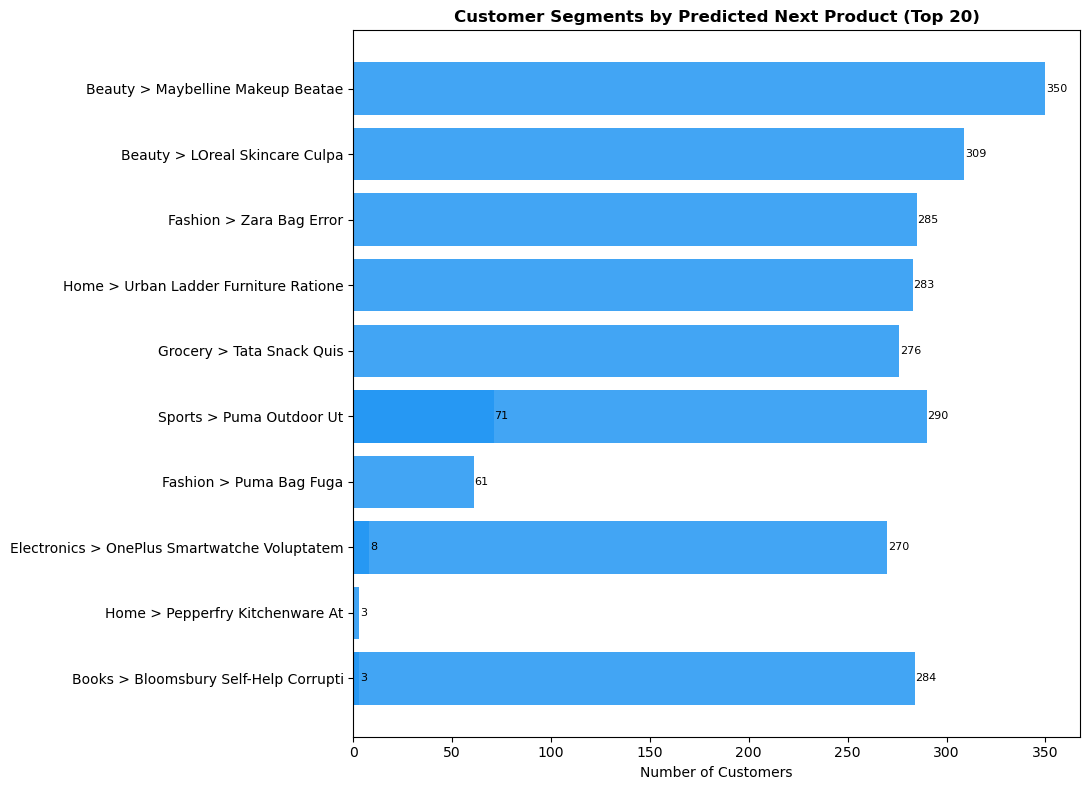

Largest segment: 'Beauty > Maybelline Makeup Beatae' — 350 customers


In [31]:
top20 = segments_df.head(20)
fig, ax = plt.subplots(figsize=(11,8))
bars = ax.barh(top20['segment_label'][::-1], top20['customer_count'][::-1],
               color='#2196F3', alpha=0.85)
ax.set_xlabel('Number of Customers')
ax.set_title('Customer Segments by Predicted Next Product (Top 20)', fontweight='bold')
for bar, val in zip(bars, top20['customer_count'][::-1]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=8)
plt.tight_layout(); plt.show()

print(f"Largest segment: '{segments_df.iloc[0]['segment_label']}'"
      f" — {segments_df.iloc[0]['customer_count']} customers")


---
## Stage 8 — Write Predictions & Segments to PostgreSQL

In [32]:
def write_to_db(predictions_df, segments_df):
    try:
        from db_connector import DBConnector
        db = DBConnector()
        if not db.health_check():
            raise ConnectionError("DB not available")

        n_pred = db.write_predictions(predictions_df)
        n_seg  = db.write_segments(
            segments_df.rename(columns={
                'recommended_product_name': 'recommended_product_name',
                'predicted_next_category' : 'predicted_next_category',
            })
        )
        print(f"Written to PostgreSQL: {n_pred} predictions, {n_seg} segments")
        return True
    except Exception as e:
        print(f"DB write skipped ({e}) — saving to CSV instead")
        predictions_df.to_csv('output_next_product_predictions.csv', index=False)
        segments_df.drop(columns='customer_ids',errors='ignore').to_csv(
            'output_customer_segments.csv', index=False)
        print("Saved: output_next_product_predictions.csv")
        print("Saved: output_customer_segments.csv")
        return False

write_to_db(predictions_df, segments_df)


Written to PostgreSQL: 2493 predictions, 13 segments


True

In [33]:
# Campaign system integration preview
print("=" * 60)
print("  CAMPAIGN DISPATCH QUEUE (pending segments)")
print("=" * 60)
top_segs = segments_df.head(10)[['segment_label','customer_count','avg_confidence']]
top_segs['campaign_action'] = top_segs['predicted_next_category'].apply(
    lambda c: f"Send '{c}' product offer") if 'predicted_next_category' in top_segs.columns else "Send offer"
for _, r in segments_df.head(5).iterrows():
    print(f"  Segment : {r['segment_label']}")
    print(f"  Audience: {r['customer_count']} customers")
    print(f"  Action  : Target with {r['predicted_next_category']} campaign")
    print()


  CAMPAIGN DISPATCH QUEUE (pending segments)
  Segment : Beauty > Maybelline Makeup Beatae
  Audience: 350 customers
  Action  : Target with Beauty campaign

  Segment : Beauty > LOreal Skincare Culpa
  Audience: 309 customers
  Action  : Target with Beauty campaign

  Segment : Sports > Puma Outdoor Ut
  Audience: 290 customers
  Action  : Target with Sports campaign

  Segment : Fashion > Zara Bag Error
  Audience: 285 customers
  Action  : Target with Fashion campaign

  Segment : Books > Bloomsbury Self-Help Corrupti
  Audience: 284 customers
  Action  : Target with Books campaign



---
## Stage 9 — Flask API

In [36]:
import lightgbm as lgb

for file in [
    "models/stage1_category_model.lgb",
    "models/stage2_lambdarank_model.lgb"
]:
    try:
        model = lgb.Booster(model_file=file)
        print(f"✅ {file}")
        print("Trees:", model.num_trees())
    except Exception as e:
        print(f"❌ {file}")
        print("ERROR:", e)

✅ models/stage1_category_model.lgb
Trees: 231
✅ models/stage2_lambdarank_model.lgb
Trees: 1
